In [1]:
from typing import TypedDict
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [4]:
class ArticleState(TypedDict):
    article: str

    grammar_feedback: str
    seo_feedback: str
    fact_feedback: str

    final_feedback: str

In [5]:
def grammar_review(state: ArticleState):
    prompt = f"""
    You are an expert English editor.

    Review ONLY the grammar of the following article.

    Do not comment on SEO.
    Do not comment on factual accuracy.

    Article:
    {state['article']}

    Give a short grammar review.
    """

    response = llm.invoke(prompt)

    return {
        "grammar_feedback": response.content
    }

In [6]:
def seo_review(state: ArticleState):
    prompt = f"""
    You are an SEO Expert.

    Review ONLY the SEO quality of the article.

    Do not comment on grammar.
    Do not comment on factual accuracy.

    Article:
    {state['article']}

    Give a short SEO review.
    """

    response = llm.invoke(prompt)
    return {
        "seo_feedback": response.content
    }

In [7]:
def fact_review(state: ArticleState):
    prompt = f"""
    You are an expert fact checker.

    Review ONLY the factual accuracy of the article.

    Do not comment on grammar.
    Do not comment on SEO.

    Article:
    {state['article']}

    Identify any factual inaccuracies or confirm that the information appears accurate..
    """

    response = llm.invoke(prompt)
    return {
        "fact_feedback": response.content
    }

In [28]:
def final_review(state: ArticleState):
    prompt = f"""
    You are an expert article reviewer..
    Below are the evaluations from the different reivews.

    Grammar:
    {state['grammar_feedback']}

    SEO:
    {state['seo_feedback']}

    Facts:
    {state['fact_feedback']}

    Based on all three reviews, decide whether this article is ready for publication.

    Provide a short final recommendation.

    """
    response = llm.invoke(prompt)
    return {
        "final_feedback": response.content
    }

In [29]:
builder = StateGraph(ArticleState)

In [30]:
builder.add_node('grammar_review', grammar_review)
builder.add_node('seo_review', seo_review)
builder.add_node('fact_review', fact_review)
builder.add_node('final_review', final_review)

In [31]:
builder.add_edge(START, "grammar_review")
builder.add_edge(START, "seo_review")
builder.add_edge(START, "fact_review")

In [32]:
builder.add_edge("grammar_review", "final_review") 
builder.add_edge("seo_review", "final_review") 
builder.add_edge("fact_review", "final_review") 

In [33]:
builder.add_edge('final_review', END)

In [34]:
graph = builder.compile()

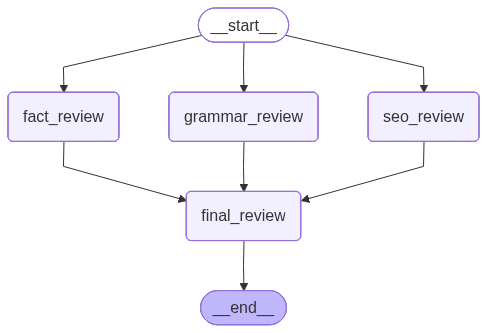

In [35]:
graph

In [36]:
initial_state = {
    "article": """
Artificial Intelligence (AI) is changing many industries around the world.
It helps businesses automate repetitive tasks, improve customer service,
and analyze large amounts of data quickly.

Many companies use AI-powered chatbots to answer customer questions 24 hours a day.
Machine learning is a branch of AI that allows computers to learn from data
without being explicitly programmed.

However, AI also brings challenges such as data privacy concerns,
ethical issues, and the possibility of job displacement.
Organizations should adopt AI responsibly and ensure human oversight
when making important decisions.

Overall, AI is becoming an essential technology that can improve productivity,
innovation, and decision-making across healthcare, finance, education,
and many other industries.
""",

    "grammar_feedback": "",
    "seo_feedback": "",
    "fact_feedback": "",
    "final_feedback": ""
}

In [37]:
result = graph.invoke(initial_state)

In [38]:
print("=" * 60)
print("GRAMMAR REVIEW")
print("=" * 60)
print(result["grammar_feedback"])

print("\n" + "=" * 60)
print("SEO REVIEW")
print("=" * 60)
print(result["seo_feedback"])

print("\n" + "=" * 60)
print("FACT REVIEW")
print("=" * 60)
print(result["fact_feedback"])

print("\n" + "=" * 60)
print("FINAL REVIEW")
print("=" * 60)
print(result["final_feedback"])

GRAMMAR REVIEW
The article's grammar is generally sound. Here are a few minor suggestions for improvement:

* Consider using a more formal tone by changing "It helps businesses" to "It enables businesses" or "Businesses can benefit from AI as it helps" to improve sentence structure.
* In the sentence "Many companies use AI-powered chatbots to answer customer questions 24 hours a day," consider adding "every day" or "seven days a week" to clarify the meaning of "24 hours a day."
* The sentence "Organizations should adopt AI responsibly and ensure human oversight when making important decisions" is a complete sentence, but it could be connected to the previous sentence with a transition word, such as "Therefore" or "Thus," to improve the flow of the text.
* The phrase "across healthcare, finance, education, and many other industries" is a bit wordy; consider shortening it to "across various industries, including healthcare, finance, and education."

Overall, the grammar is clear and effe